# 🚗 ALPR Complet - YOLOv8 + Fast-Plate-OCR

Pipeline optimisé pour la reconnaissance de plaques d'immatriculation :
1. **YOLOv8** (ton modèle Roboflow) → Détection de la plaque
2. **fast-plate-ocr** → OCR spécialisé plaques (220k+ plaques, 40+ pays)

---

## 1. Installation

In [ ]:
# Installation des dépendances
# !pip install ultralytics fast-plate-ocr[onnx-gpu] opencv-python matplotlib pandas -q
# print("✅ Installation terminée !")

## 2. Imports et Configuration

In [2]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from fast_plate_ocr import LicensePlateRecognizer
from datetime import datetime

plt.rcParams['figure.figsize'] = [12, 8]
%matplotlib inline

print("✅ Imports réussis !")

✅ Imports réussis !


In [3]:
# ⚠️ MODIFIER CE CHEMIN selon votre configuration
WORK_DIR = "/mnt/c/DEV/jedha/fullstack_wsl/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe"
os.chdir(WORK_DIR)
print(f"📁 Répertoire : {os.getcwd()}")

📁 Répertoire : /mnt/c/DEV/jedha/fullstack_wsl/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe


## 3. Chargement des Modèles

In [4]:
# Charger ton modèle YOLOv8 entraîné sur Roboflow
lp_models = sorted(glob.glob('runs/detect/LP_*/weights/best.pt'))
print(f"🔍 Modèles disponibles : {lp_models}")

LP_MODEL_PATH = lp_models[-1] if lp_models else 'runs/detect/LP_roboflow/weights/best.pt'
print(f"\n📦 Chargement YOLO : {LP_MODEL_PATH}")
model_yolo = YOLO(LP_MODEL_PATH)
print("✅ YOLOv8 chargé !")

🔍 Modèles disponibles : ['runs/detect/LP_roboflow/weights/best.pt']

📦 Chargement YOLO : runs/detect/LP_roboflow/weights/best.pt
✅ YOLOv8 chargé !


In [5]:
# Charger fast-plate-ocr avec le modèle global (40+ pays)
print("📦 Chargement fast-plate-ocr (téléchargement du modèle si première fois)...")
ocr = LicensePlateRecognizer('global-plates-mobile-vit-v2-model')
print("✅ fast-plate-ocr chargé !")

📦 Chargement fast-plate-ocr (téléchargement du modèle si première fois)...
*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:539 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************
✅ fast-plate-ocr chargé !


2026-02-09 08:59:07.446867844 [E:onnxruntime:Default, provider_bridge_ort.cc:2336 TryGetProviderInfo_TensorRT] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1957 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/alpr_env/lib/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.10: cannot open shared object file: No such file or directory



## 4. Fonctions du Pipeline ALPR

In [6]:
def detect_plates(image, model, conf=0.5):
    """
    Détecte les plaques avec YOLOv8.
    
    Returns:
        Liste de dict avec 'bbox', 'confidence', 'plate_img'
    """
    results = model.predict(image, conf=conf, verbose=False)
    
    plates = []
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = box.conf[0].item()
            
            # Extraire l'image de la plaque
            plate_img = image[y1:y2, x1:x2]
            
            plates.append({
                'bbox': (x1, y1, x2, y2),
                'confidence': confidence,
                'plate_img': plate_img
            })
    
    return plates

In [7]:
def read_plate(plate_img, ocr_model):
    """
    Lit les caractères avec fast-plate-ocr.
    """
    if plate_img is None or plate_img.size == 0:
        return "", 0.0
    
    # Convertir en niveaux de gris (1 canal) - requis par fast-plate-ocr
    if len(plate_img.shape) == 3:
        plate_gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    else:
        plate_gray = plate_img
    
    try:
        predictions = ocr_model.run(plate_gray)
        
        if predictions and len(predictions) > 0:
            text = predictions[0] if isinstance(predictions[0], str) else str(predictions[0])
            text = text.upper().replace(' ', '').replace('-', '')
            confidence = 0.95
        else:
            text = ""
            confidence = 0.0
    except Exception as e:
        print(f"⚠️ Erreur OCR: {e}")
        text = ""
        confidence = 0.0
    
    return text, confidence

In [8]:
def process_image(image_path, model_yolo, ocr_model, conf_detect=0.5):
    """
    Pipeline complet : Détection YOLO + OCR fast-plate-ocr.
    
    Returns:
        img_annotated: Image avec annotations
        results: Liste des plaques détectées et lues
    """
    # Charger l'image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Impossible de charger : {image_path}")
    
    img_annotated = img.copy()
    results = []
    
    # Étape 1 : Détecter les plaques avec YOLO
    plates = detect_plates(img, model_yolo, conf_detect)
    
    for i, plate in enumerate(plates):
        x1, y1, x2, y2 = plate['bbox']
        plate_img = plate['plate_img']
        
        # Étape 2 : Lire la plaque avec fast-plate-ocr
        plate_text, ocr_conf = read_plate(plate_img, ocr_model)
        
        results.append({
            'id': i + 1,
            'bbox': plate['bbox'],
            'text': plate_text,
            'confidence_detect': plate['confidence'],
            'confidence_ocr': ocr_conf
        })
        
        # Annoter l'image
        # Rectangle vert autour de la plaque
        cv2.rectangle(img_annotated, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Texte de la plaque
        text = plate_text if plate_text else "???"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.0
        thickness = 2
        
        # Calculer la taille du texte
        (tw, th), baseline = cv2.getTextSize(text, font, font_scale, thickness)
        
        # Fond pour le texte (meilleure lisibilité)
        cv2.rectangle(img_annotated, (x1, y1 - th - 10), (x1 + tw + 10, y1), (0, 255, 0), -1)
        
        # Texte noir sur fond vert
        cv2.putText(img_annotated, text, (x1 + 5, y1 - 5), font, font_scale, (0, 0, 0), thickness)
    
    return img_annotated, results

In [9]:
def display_result(img_annotated, results, title="ALPR"):
    """
    Affiche l'image annotée et les résultats.
    """
    # Convertir BGR -> RGB pour matplotlib
    img_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(14, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()
    
    # Afficher les résultats textuels
    print("\n" + "="*60)
    print("📋 RÉSULTATS DE LA RECONNAISSANCE")
    print("="*60)
    
    if results:
        for r in results:
            print(f"\n🚗 Plaque #{r['id']}")
            print(f"   📝 Texte lu    : {r['text'] if r['text'] else '❌ Non lisible'}")
            print(f"   🎯 Conf. YOLO  : {r['confidence_detect']:.1%}")
            print(f"   🔤 Conf. OCR   : {r['confidence_ocr']:.1%}")
            print(f"   📍 Position    : {r['bbox']}")
    else:
        print("\n❌ Aucune plaque détectée")
    
    print("\n" + "="*60)

In [10]:
def save_result(img_annotated, output_path):
    """
    Sauvegarde l'image annotée.
    """
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cv2.imwrite(output_path, img_annotated)
    print(f"💾 Sauvegardé : {output_path}")

## 5. Test sur une Image

In [20]:
# Lister les images de test disponibles
test_images = glob.glob('sample/*.jpg')
print(f"🖼️ {len(test_images)} images de test disponibles")
print("\nExemples :")
for img in test_images[:5]:
    print(f"   - {img}")

🖼️ 135 images de test disponibles

Exemples :
   - sample/00026.jpg
   - sample/00064.jpg
   - sample/00427.jpg
   - sample/01016.jpg
   - sample/10013.jpg


🔍 Test sur : sample/CarLongPlate488_jpg.rf.7508cc156db24f134b469cc844927fe9.jpg


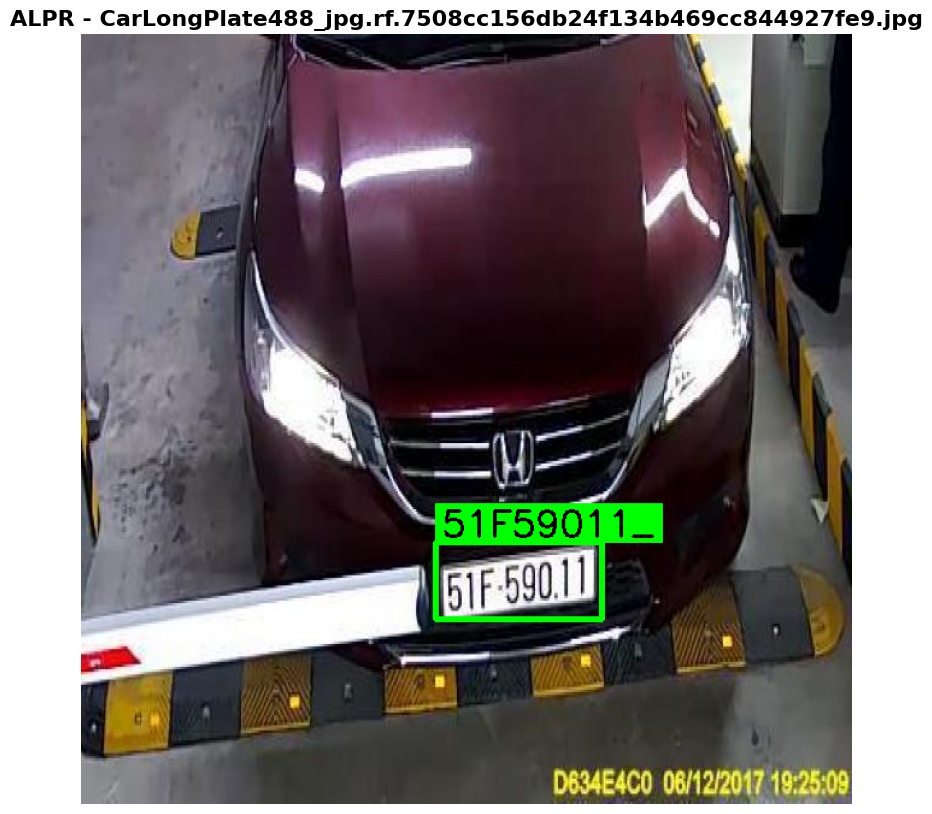


📋 RÉSULTATS DE LA RECONNAISSANCE

🚗 Plaque #1
   📝 Texte lu    : 51F59011_
   🎯 Conf. YOLO  : 83.4%
   🔤 Conf. OCR   : 95.0%
   📍 Position    : (294, 422, 432, 486)



In [22]:
# ⬇️ MODIFIER ICI pour tester une image spécifique
TEST_IMAGE = test_images[100] if test_images else 'test.jpg'

print(f"🔍 Test sur : {TEST_IMAGE}")

# Lancer le pipeline
img_result, detections = process_image(TEST_IMAGE, model_yolo, ocr, conf_detect=0.5)

# Afficher
display_result(img_result, detections, title=f"ALPR - {os.path.basename(TEST_IMAGE)}")

In [26]:
# Sauvegarder le résultat
output_dir = 'results'
os.makedirs(output_dir, exist_ok=True)

# Sauvegarder le résultat
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_result(img_result, f'{output_dir}/alpr_fastocr_{timestamp}.jpg')

💾 Sauvegardé : results/alpr_fastocr_20260209_090931.jpg


## 6. Test sur Plusieurs Images

In [31]:
import pandas as pd

# Traiter les 10 premières images de test
all_results = []
n_images = min(20, len(test_images))

print(f"🔄 Traitement de {n_images} images...\n")

for i, img_path in enumerate(test_images[:n_images]):
    try:
        img_result, detections = process_image(img_path, model_yolo, ocr)
        
        for det in detections:
            all_results.append({
                'image': os.path.basename(img_path),
                'plate_text': det['text'],
                'conf_detect': f"{det['confidence_detect']:.1%}",
                'conf_ocr': f"{det['confidence_ocr']:.1%}"
            })
        
        # Sauvegarder
        basename = os.path.basename(img_path).replace('.jpg', '_fast_ocr_result.jpg')
        save_result(img_result, f'results/{basename}')
        
        print(f"✅ [{i+1}/{n_images}] {os.path.basename(img_path)} → {[d['text'] for d in detections]}")
        s
    except Exception as e:
        print(f"❌ [{i+1}/{n_images}] {os.path.basename(img_path)} → Erreur: {e}")

print(f"\n✅ Terminé ! {len(all_results)} plaques détectées et lues")

🔄 Traitement de 20 images...

💾 Sauvegardé : results/00026_fast_ocr_result.jpg
✅ [1/20] 00026.jpg → ['240JV____', '496TTM___']
❌ [1/20] 00026.jpg → Erreur: name 's' is not defined
💾 Sauvegardé : results/00064_fast_ocr_result.jpg
✅ [2/20] 00064.jpg → ['151ZZY___']
❌ [2/20] 00064.jpg → Erreur: name 's' is not defined
💾 Sauvegardé : results/00427_fast_ocr_result.jpg
✅ [3/20] 00427.jpg → []
❌ [3/20] 00427.jpg → Erreur: name 's' is not defined
💾 Sauvegardé : results/01016_fast_ocr_result.jpg
✅ [4/20] 01016.jpg → ['702SHH___']
❌ [4/20] 01016.jpg → Erreur: name 's' is not defined
💾 Sauvegardé : results/10013_fast_ocr_result.jpg
✅ [5/20] 10013.jpg → ['51F15585_']
❌ [5/20] 10013.jpg → Erreur: name 's' is not defined
💾 Sauvegardé : results/CarLongPlate101_jpg.rf.094b5dbcfcd40c35c64a0e0190df23e2_fast_ocr_result.jpg
✅ [6/20] CarLongPlate101_jpg.rf.094b5dbcfcd40c35c64a0e0190df23e2.jpg → ['30N4616__']
❌ [6/20] CarLongPlate101_jpg.rf.094b5dbcfcd40c35c64a0e0190df23e2.jpg → Erreur: name 's' is not defi

In [15]:
# Tableau récapitulatif
if all_results:
    df = pd.DataFrame(all_results)
    print("\n📊 Récapitulatif des détections :")
    display(df)
else:
    print("Aucune détection")


📊 Récapitulatif des détections :


,image,plate_text,conf_detect,conf_ocr
0,0002a5b67e5f0909_jpg.rf.07ca41e79eb878b14032f6...,DS08PCZ__,75.2%,95.0%
1,0002a5b67e5f0909_jpg.rf.07ca41e79eb878b14032f6...,FHN091F__,73.6%,95.0%
2,000812dcf304a8e7_jpg.rf.559f904bc045f68ee94779...,63771BA__,75.4%,95.0%
3,0010f4c10f7ab07e_jpg.rf.92344aa620e23aacc49027...,6D065____,65.6%,95.0%
4,001cdd25e148cd36_jpg.rf.eca53e55e3cf5986bcfd95...,614697___,76.7%,95.0%
5,002519f868563098_jpg.rf.b9450b9265c92d8d3bd96b...,XUR6783__,78.1%,95.0%
6,0026c246d5c33bea_jpg.rf.782def291f7881f554c7a8...,B137012__,72.4%,95.0%
7,0026c246d5c33bea_jpg.rf.782def291f7881f554c7a8...,SM050FO__,67.7%,95.0%
8,0026c246d5c33bea_jpg.rf.782def291f7881f554c7a8...,SM11HC___,50.1%,95.0%
9,0039ac4bfb8bd69d_jpg.rf.8ed0bdac228b8da2b163f8...,PN52XLL__,79.1%,95.0%


## 7. Test avec une Image Personnalisée

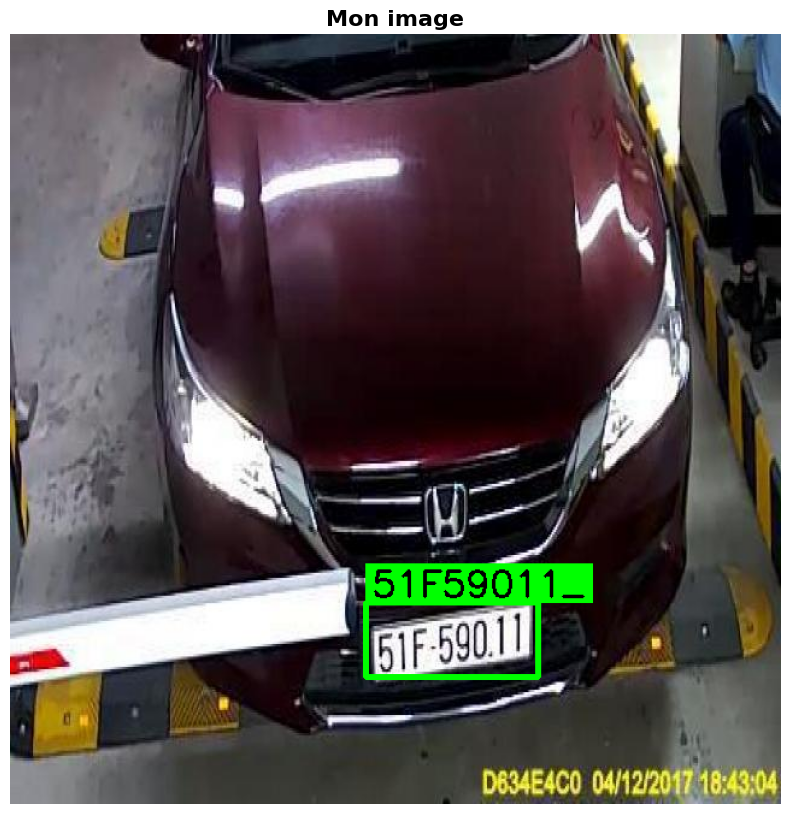


📋 RÉSULTATS DE LA RECONNAISSANCE

🚗 Plaque #1
   📝 Texte lu    : 51F59011_
   🎯 Conf. YOLO  : 82.5%
   🔤 Conf. OCR   : 95.0%
   📍 Position    : (295, 472, 438, 534)

💾 Sauvegardé : results/mon_image_result.jpg


In [28]:
# ⬇️ METTEZ LE CHEMIN DE VOTRE IMAGE ICI
MY_IMAGE = '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe/License-Plate-Recognition-4/valid/images/CarLongPlate98_jpg.rf.1a1813531cae3bbcc6d256ac1e84e401.jpg'

# Décommenter pour tester :
img_result, detections = process_image(MY_IMAGE, model_yolo, ocr)
display_result(img_result, detections, title="Mon image")
save_result(img_result, 'results/mon_image_result.jpg')

## 8. Visualisation Galerie

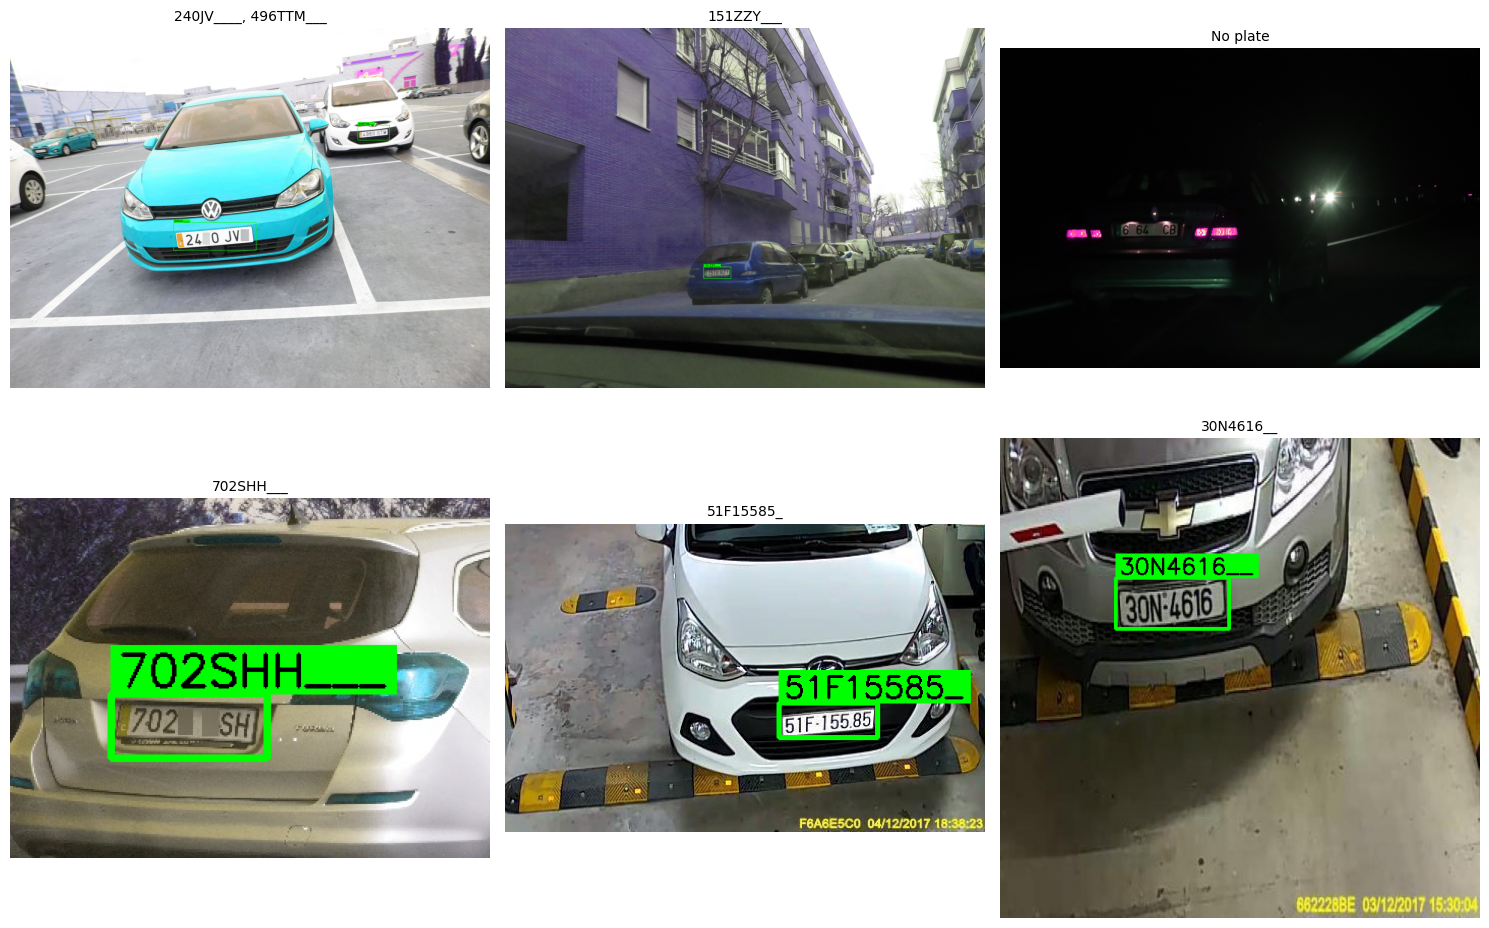

In [29]:
def show_gallery(images_paths, model_yolo, ocr_model, n_cols=3):
    """
    Affiche une galerie d'images avec leurs détections.
    """
    n_images = len(images_paths)
    n_rows = (n_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten() if n_images > 1 else [axes]
    
    for i, img_path in enumerate(images_paths):
        try:
            img_result, detections = process_image(img_path, model_yolo, ocr_model)
            img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img_rgb)
            title = ", ".join([d['text'] for d in detections if d['text']]) or "No plate"
            axes[i].set_title(title, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error: {e}", ha='center')
            axes[i].axis('off')
    
    # Cacher les axes vides
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Afficher une galerie de 6 images
show_gallery(test_images[:6], model_yolo, ocr, n_cols=3)

## 9. Benchmark de Performance

In [30]:
import time

# Mesurer le temps d'inférence
n_tests = 10
times = []

print(f"⏱️ Benchmark sur {n_tests} images...")

for img_path in test_images[:n_tests]:
    start = time.time()
    img_result, detections = process_image(img_path, model_yolo, ocr)
    elapsed = time.time() - start
    times.append(elapsed)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"\n📊 Résultats :")
print(f"   - Temps moyen : {avg_time*1000:.1f} ms/image")
print(f"   - FPS estimé  : {fps:.1f} images/seconde")

⏱️ Benchmark sur 10 images...

📊 Résultats :
   - Temps moyen : 136.1 ms/image
   - FPS estimé  : 7.3 images/seconde


---

## 📝 Notes

### Modèles utilisés :
- **Détection** : YOLOv8n entraîné sur Roboflow (~24k images)
- **OCR** : fast-plate-ocr `global-plates-mobile-vit-v2-model` (220k+ plaques, 40+ pays)

### Pourquoi fast-plate-ocr ?
- Entraîné spécifiquement sur des plaques d'immatriculation
- Reconnaissance caractère par caractère (pas de recherche de mots)
- Support multi-pays (Europe, USA, Asie, Amérique du Sud...)
- Très rapide grâce à ONNX Runtime

### Autres modèles OCR disponibles :
- `cct-xs-v1-global-model` : Plus léger, légèrement moins précis
- `european-plates-mobile-vit-v2-model` : Optimisé Europe

---
*ALPR Pipeline - YOLOv8 + fast-plate-ocr*